<a href="https://colab.research.google.com/github/Janina-Ing/Analisis-y-visualizacion-de-datos/blob/main/WebScraping_Practica_Alejandrina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Celda 1: Instalacion de librerias
!pip install requests beautifulsoup4 lxml selenium pandas openpyxl
!apt-get update
!apt-get install -y chromium-chromedriver
# Verificar instalacion
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
import pandas as pd
print('Todas las librerias instaladas correctamente')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://r2u.stat.illino

In [2]:
# Montar Google Drive para guardar archivos
from google.colab import drive
drive.mount('/content/drive')
# Ahora puedes guardar archivos en tu Drive:
# df.to_csv('/content/drive/MyDrive/datos_scraping.csv')

Mounted at /content/drive


In [3]:
# Celda 2: Primera solicitud HTTP
import requests
from bs4 import BeautifulSoup
# Realizar solicitud GET al sitio
url = 'http://books.toscrape.com'
response = requests.get(url)
# Verificar que la solicitud fue exitosa
print(f'Status Code: {response.status_code}') # 200 = exito
print(f'Encoding: {response.encoding}')
print(f'Tamano del HTML: {len(response.text)} caracteres')
# Parsear el HTML con BeautifulSoup
soup = BeautifulSoup(response.text,'lxml')
# Ver el titulo de la pagina
print(f'Titulo: {soup.title.string}')

Status Code: 200
Encoding: ISO-8859-1
Tamano del HTML: 51294 caracteres
Titulo: 
    All products | Books to Scrape - Sandbox



In [4]:
# Celda 3: Extraer datos del primer libro
# Encontrar el primer articulo de producto
primer_libro = soup.find('article', class_='product_pod')
# Extraer titulo (esta en el atributo title del enlace dentro de <h3>)
titulo = primer_libro.h3.a['title']
print(f'Titulo: {titulo}')
# Extraer precio
# Corrección: El método find espera el nombre de la etiqueta como primer argumento, luego los atributos.
precio = primer_libro.find('p', class_='price_color').text
print(f'Precio: {precio}')
# Extraer calificacion (esta como clase CSS: 'star-rating Three')
# Corrección: 1. 'star-rating' debe ser un string literal. 2. 'class' es palabra reservada, usar ['class'].
# Buscamos un <p> que contenga 'star-rating' en sus clases y extraemos la segunda clase.
calificacion_tag = primer_libro.find('p', class_=lambda c: c and 'star-rating' in c)
calificacion = calificacion_tag['class'][1] if calificacion_tag else 'No info'
print(f'Calificacion: {calificacion}')
# Extraer disponibilidad
# Corrección: El método find espera el nombre de la etiqueta como primer argumento, luego los atributos.
disponible = primer_libro.find('p', class_='instock availability')
stock = disponible.text.strip() if disponible else 'Sin info';
print(f'Disponibilidad: {stock}')

Titulo: A Light in the Attic
Precio: Â£51.77
Calificacion: Three
Disponibilidad: In stock


In [5]:
# Celda 4: Extraer todos los libros de la pagina 1
libros = soup.find_all('article', class_='product_pod')
print(f'Libros encontrados en pagina 1: {len(libros)}')
datos = []
for libro in libros:
    titulo = libro.h3.a['title']
    precio_texto = libro.find('p', class_='price_color').text
    # Limpiar precio: quitar simbolo y convertir a float
    # It appears the pound symbol might be incorrectly encoded as 'Â£'
    # when parsed into response.text. Replacing 'Â£' to handle this.
    precio = float(precio_texto.replace('Â£', '')) # Fix: Reemplazar 'Â£' para corregir el problema de codificación.
    # Extraer calificacion (esta como clase CSS: 'star-rating Three')
    calificacion_tag = libro.find('p', class_=lambda c: c and 'star-rating' in c)
    calificacion = calificacion_tag['class'][1] if calificacion_tag else 'No info'
    # Extraer disponibilidad
    stock_tag = libro.find('p', class_='instock availability')
    disponible = 'Si' if stock_tag and 'In stock' in stock_tag.text else 'No'
    datos.append({
        'titulo': titulo,
        'precio_gbp': precio,
        'calificacion': calificacion,
        'disponible': disponible
    })

Libros encontrados en pagina 1: 20


In [6]:
# Celda 5: Scraping de TODAS las paginas (50 paginas)
import time
import pandas as pd # Ensure pandas is imported

todos_los_libros = []
base_url = 'http://books.toscrape.com/catalogue/page-{}.html'

for pagina in range(1, 51): # 50 paginas
    url = base_url.format(pagina)
    response = requests.get(url)

    if response.status_code != 200:
        print(f'Error en pagina {pagina}: {response.status_code}')
        continue

    soup = BeautifulSoup(response.text, 'lxml')
    libros = soup.find_all('article', class_='product_pod')

    for libro in libros:
        titulo = libro.h3.a['title']
        precio_texto = libro.find('p', class_='price_color').text
        # Limpiar precio: quitar simbolo y convertir a float, manejando la codificación 'Â£'
        precio = float(precio_texto.replace('Â£', ''))

        # Extraer calificacion (esta como clase CSS: 'star-rating Three')
        calificacion_tag = libro.find('p', class_=lambda c: c and 'star-rating' in c)
        calificacion = calificacion_tag['class'][1] if calificacion_tag else 'No info'

        # Extraer disponibilidad
        stock_tag = libro.find('p', class_='instock availability')
        disponible = 'Si' if stock_tag and 'In stock' in stock_tag.text else 'No'

        todos_los_libros.append({
            'titulo': titulo,
            'precio_gbp': precio,
            'calificacion': calificacion,
            'disponible': disponible,
            'pagina_origen': pagina
        })

    # Pausa de cortesia entre solicitudes (buena practica)
    time.sleep(0.5)

    if pagina % 10 == 0:
        print(f'Paginas procesadas: {pagina}/50')

df_completo = pd.DataFrame(todos_los_libros)
print(f'\nTotal de libros extraidos: {len(df_completo)}')
print(df_completo.head(10))

Paginas procesadas: 10/50
Paginas procesadas: 20/50
Paginas procesadas: 30/50
Paginas procesadas: 40/50
Paginas procesadas: 50/50

Total de libros extraidos: 1000
                                              titulo  precio_gbp calificacion  \
0                               A Light in the Attic       51.77        Three   
1                                 Tipping the Velvet       53.74          One   
2                                         Soumission       50.10          One   
3                                      Sharp Objects       47.82         Four   
4              Sapiens: A Brief History of Humankind       54.23         Five   
5                                    The Requiem Red       22.65          One   
6  The Dirty Little Secrets of Getting Your Dream...       33.34         Four   
7  The Coming Woman: A Novel Based on the Life of...       17.93        Three   
8  The Boys in the Boat: Nine Americans and Their...       22.60         Four   
9                          

In [7]:
# 1. Agregar el repositorio de Debian (que no usa Snap para Chromium)
!apt-get update
!apt-get install -y wget gnupg
!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list

# 2. Instalar Google Chrome Real (en lugar de Chromium de Ubuntu)
!apt-get update
!apt-get install -y google-chrome-stable

# 3. Instalar un gestor automático para el Driver (esto soluciona las rutas para siempre)
!pip install webdriver-manager

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Fetched 56.9 kB in 11s (5,172 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependenc

In [8]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from webdriver_manager.core.os_manager import ChromeType

# Configuración de opciones
chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')

try:
    # Esto descargará el driver correcto automáticamente y lo configurará
    service = Service(ChromeDriverManager(chrome_type=ChromeType.GOOGLE).install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    driver.get("https://www.google.com")
    print(f" ¡POR FIN! Conexión exitosa. Título: {driver.title}")

except Exception as e:
    print(f" Error persistente: {e}")

 ¡POR FIN! Conexión exitosa. Título: Google


In [9]:
# Actualizar e instalar Chromium y ChromeDriver
!apt-get update
!apt-get install -y chromium-browser chromium-chromedriver

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://dl.google.com/linux/chrome/deb stable InRelease
Get:6 https://dl.google.com/linux/chrome-stable/deb stable InRelease [1,825 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:10 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1,219 B]
Ign:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Ign:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Ign:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Ign:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Ign:11 https://ppa.laun

In [10]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from webdriver_manager.core.os_manager import ChromeType

# 1. Configuración moderna
chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')

# 2. Iniciar el navegador (Este comando reemplaza al tuyo que da error)
try:
    # Usamos ChromeDriverManager para que él mismo busque el driver correcto
    service = Service(ChromeDriverManager(chrome_type=ChromeType.GOOGLE).install())
    driver = webdriver.Chrome(service=service, options=chrome_options)
    print(" Navegador Chrome iniciado correctamente con la nueva configuración")
except Exception as e:
    print(f" Error al iniciar: {e}")

 Navegador Chrome iniciado correctamente con la nueva configuración


In [11]:
# Siguiente paso lógico: Abrir una URL
url = "https://www.google.com" # Cambia esto por la URL que te pida tu práctica
driver.get(url)

print(f"Página cargada con éxito: {driver.title}")

Página cargada con éxito: Google


In [12]:
# --- Celda 7: Configurar Selenium en Colab (modo headless) ---
# (Adaptado del PDF para que funcione en 2026)

from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Usamos las opciones que ya definimos arriba
# Si quieres volver a definirlas como dice tu PDF:
chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
chrome_options.add_argument('--disable-gpu')

# IMPORTANTE: No uses la línea del PDF que decía 'webdriver.Chrome(options=chrome_options)'
# porque le falta el 'service' que instalamos. Usa esta:
driver = webdriver.Chrome(service=service, options=chrome_options)

print(" Navegador Chrome iniciado en modo headless")

 Navegador Chrome iniciado en modo headless


In [13]:
# --- Celda 8: Scraping con Selenium - Quotes con JavaScript ---
import time
import pandas as pd # Para crear la tabla al final

url = 'http://quotes.toscrape.com/js/'
driver.get(url)

# Esperar a que cargue el contenido dinámico
# (Le damos 5 segundos para estar seguros en Colab)
time.sleep(5)

# Extraer todas las citas buscando por la clase 'quote'
quotes = driver.find_elements(By.CLASS_NAME, 'quote')
print(f'Citas encontradas: {len(quotes)}')

datos_citas = []

for quote in quotes:
    # Extraemos el texto, el autor y las etiquetas (tags)
    texto = quote.find_element(By.CLASS_NAME, 'text').text
    autor = quote.find_element(By.CLASS_NAME, 'author').text

    # Las etiquetas son varias, así que las unimos con una coma
    tags_elems = quote.find_elements(By.CLASS_NAME, 'tag')
    tags = ', '.join([t.text for t in tags_elems])

    datos_citas.append({
        'texto': texto,
        'autor': autor,
        'tags': tags
    })

# Convertir la lista de diccionarios en un DataFrame (Tabla)
df_citas = pd.DataFrame(datos_citas)

# Mostrar los primeros resultados
print("\n--- Resultados Extraídos ---")
print(df_citas.head())

Citas encontradas: 10

--- Resultados Extraídos ---
                                               texto            autor  \
0  “The world as we have created it is a process ...  Albert Einstein   
1  “It is our choices, Harry, that show what we t...     J.K. Rowling   
2  “There are only two ways to live your life. On...  Albert Einstein   
3  “The person, be it gentleman or lady, who has ...      Jane Austen   
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe   

                                           tags  
0        change, deep-thoughts, thinking, world  
1                            abilities, choices  
2  inspirational, life, live, miracle, miracles  
3              aliteracy, books, classic, humor  
4                    be-yourself, inspirational  


In [14]:
# --- Celda 9: Navegar múltiples páginas con Selenium ---
import time

todos_datos = []
driver.get('http://quotes.toscrape.com/js/')
time.sleep(2)

pagina_actual = 1

while pagina_actual <= 10:  # Máximo 10 páginas
    print(f"Scrapeando página {pagina_actual}...")

    # Extraer citas de la página actual
    quotes = driver.find_elements(By.CLASS_NAME, 'quote')

    for quote in quotes:
        texto = quote.find_element(By.CLASS_NAME, 'text').text
        autor = quote.find_element(By.CLASS_NAME, 'author').text
        todos_datos.append({
            'texto': texto,
            'autor': autor,
            'pagina': pagina_actual
        })

    # Intentar ir a la siguiente página
    try:
        # Buscamos el botón "Next" dentro de la lista de navegación
        next_btn = driver.find_element(By.CSS_SELECTOR, 'li.next > a')
        next_btn.click()

        # Espera crucial: damos tiempo a que el JS cargue la nueva página
        time.sleep(2)
        pagina_actual += 1
    except:
        print(f'No hay más páginas. Última: {pagina_actual}')
        break

print(f'\n Total de citas extraídas: {len(todos_datos)}')



Scrapeando página 1...
Scrapeando página 2...
Scrapeando página 3...
Scrapeando página 4...
Scrapeando página 5...
Scrapeando página 6...
Scrapeando página 7...
Scrapeando página 8...
Scrapeando página 9...
Scrapeando página 10...
No hay más páginas. Última: 10

 Total de citas extraídas: 100


In [16]:
# --- Celda 10: Pipeline de limpieza completo ---
import pandas as pd
import numpy as np

# 1. Cargar los datos (usamos el DataFrame que ya tenemos en memoria)
# El error 'df_final' no definido ocurre porque 'df_final' se crea después en el pipeline.
# En este punto, los datos de las citas están en 'todos_datos' de la celda anterior.
# Creamos el DataFrame 'df_final' aquí para que esté disponible.
df_final = pd.DataFrame(todos_datos)
df_limpio = df_final.copy()

# --- Paso 1: Revision inicial ---
print("--- REVISION INICIAL ---")
print(f'Shape: {df_limpio.shape}') # Cuántas filas y columnas hay
print(f'\nTipos de datos:\n{df_limpio.dtypes}')
print(f'\nValores nulos:\n{df_limpio.isnull().sum()}')
print(f'\nDuplicados: {df_limpio.duplicated().sum()}')

# --- Paso 2: Limpieza ---

# Eliminar duplicados si los hubiera (basado en el texto de la frase)
df_limpio = df_limpio.drop_duplicates(subset='texto')

# Ejemplo de transformación: Contar cuántas palabras tiene cada frase
# (Esto agrega valor para un análisis posterior)
df_limpio['conteo_palabras'] = df_limpio['texto'].apply(lambda x: len(x.split()))

# Ejemplo de limpieza de texto: Convertir autores a mayúsculas
df_limpio['autor'] = df_limpio['autor'].str.upper()

print("\n--- REVISION FINAL ---")
print(f'Nuevo Shape: {df_limpio.shape}')
print(df_limpio.head())

--- REVISION INICIAL ---
Shape: (100, 3)

Tipos de datos:
texto     object
autor     object
pagina     int64
dtype: object

Valores nulos:
texto     0
autor     0
pagina    0
dtype: int64

Duplicados: 0

--- REVISION FINAL ---
Nuevo Shape: (100, 4)
                                               texto            autor  pagina  \
0  “The world as we have created it is a process ...  ALBERT EINSTEIN       1   
1  “It is our choices, Harry, that show what we t...     J.K. ROWLING       1   
2  “There are only two ways to live your life. On...  ALBERT EINSTEIN       1   
3  “The person, be it gentleman or lady, who has ...      JANE AUSTEN       1   
4  “Imperfection is beauty, madness is genius and...   MARILYN MONROE       1   

   conteo_palabras  
0               21  
1               16  
2               26  
3               19  
4               16  


In [17]:
# --- Celda 11: Guardar en multiples formatos ---
import sqlite3

# --- 1. Guardar como CSV (El más común) ---
df_limpio.to_csv('citas_limpias.csv', index=False, encoding='utf-8-sig')

# --- 2. Guardar como JSON (Ideal para aplicaciones web) ---
df_limpio.to_json('citas_limpias.json', orient='records', force_ascii=False, indent=2)

# --- 3. Guardar como Excel (Para reportes de negocio) ---
df_limpio.to_excel('citas_limpias.xlsx', index=False, sheet_name='Datos_Limpios')

# --- 4. Guardar en SQLite (Base de datos relacional) ---
conn = sqlite3.connect('citas_database.db')
df_limpio.to_sql('citas', conn, if_exists='replace', index=False)

# Verificar la base de datos con una consulta SQL rápida
resultado = pd.read_sql('SELECT * FROM citas LIMIT 5', conn)
print(' Datos guardados correctamente. Vista previa de SQLite:')
print(resultado[['texto', 'autor', 'conteo_palabras']])

conn.close()

 Datos guardados correctamente. Vista previa de SQLite:
                                               texto            autor  \
0  “The world as we have created it is a process ...  ALBERT EINSTEIN   
1  “It is our choices, Harry, that show what we t...     J.K. ROWLING   
2  “There are only two ways to live your life. On...  ALBERT EINSTEIN   
3  “The person, be it gentleman or lady, who has ...      JANE AUSTEN   
4  “Imperfection is beauty, madness is genius and...   MARILYN MONROE   

   conteo_palabras  
0               21  
1               16  
2               26  
3               19  
4               16  


In [18]:
# --- Celda 12: Visualización Interactiva con Plotly ---
import plotly.express as px
import pandas as pd

# 1. Preparar datos para la gráfica de Pastel (Top Autores)
top_autores = df_limpio['autor'].value_counts().reset_index()
top_autores.columns = ['Autor', 'Cantidad de Citas']

# Crear Gráfica de Pastel (Pie Chart) interactiva
fig_pie = px.pie(top_autores.head(10), # Mostramos solo los top 10 para que no se sature
                 values='Cantidad de Citas',
                 names='Autor',
                 title='Proporción de Citas por Autor (Top 10)',
                 hole=0.4, # Esto la convierte en una gráfica de dona, se ve más moderna
                 template='plotly_white') # Fondo blanco limpio

# 2. Preparar datos para la gráfica de Caja (Distribución de palabras)
# Crear Diagrama de Caja (Box Plot) interactivo
fig_box = px.box(df_limpio,
                 y='conteo_palabras',
                 title='Distribución de la Longitud de Frases (Palabras)',
                 labels={'conteo_palabras': 'Número de Palabras'},
                 points="all", # Muestra todos los puntos de datos individuales al lado
                 template='plotly_white')

# Mostrar ambas gráficas en el Colab
fig_pie.show()
fig_box.show()

In [19]:
# Celda: Parte B - Punto 4: Paginación con Clicks
import time
from selenium.webdriver.common.by import By

todos_datos = []
driver.get('http://quotes.toscrape.com/js/')
time.sleep(2) # Espera inicial

pagina_actual = 1
while pagina_actual <= 10:
    # Extraer citas de la página actual
    quotes = driver.find_elements(By.CLASS_NAME, 'quote')
    for quote in quotes:
        todos_datos.append({
            'texto': quote.find_element(By.CLASS_NAME, 'text').text,
            'autor': quote.find_element(By.CLASS_NAME, 'author').text,
            'pagina': pagina_actual
        })

    # Intentar ir a la siguiente página
    try:
        next_btn = driver.find_element(By.CSS_SELECTOR, 'li.next > a')
        next_btn.click()
        time.sleep(2) # Espera para carga de JS
        pagina_actual += 1
    except:
        print(f"No hay más páginas. Finalizado en: {pagina_actual}")
        break

df_selenium = pd.DataFrame(todos_datos)
print(f'Total citas extraídas: {len(todos_datos)}')
print(df_selenium.head())

No hay más páginas. Finalizado en: 10
Total citas extraídas: 100
                                               texto            autor  pagina
0  “The world as we have created it is a process ...  Albert Einstein       1
1  “It is our choices, Harry, that show what we t...     J.K. Rowling       1
2  “There are only two ways to live your life. On...  Albert Einstein       1
3  “The person, be it gentleman or lady, who has ...      Jane Austen       1
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe       1


In [20]:
driver.quit()

In [21]:
# --- PARTE D: Pipeline ETL Corregido ---
import requests
from bs4 import BeautifulSoup
import pandas as pd
import sqlite3
import time
import re

def run_pipeline():
    print(" Iniciando Pipeline ETL...")

    datos_libros = []
    url_base = "http://books.toscrape.com/catalogue/page-{}.html"

    for i in range(1, 4):
        print(f"Extrayendo página {i}...")
        r = requests.get(url_base.format(i))
        soup = BeautifulSoup(r.text, 'html.parser')
        books = soup.find_all('article', class_='product_pod')

        for book in books:
            titulo = book.h3.a['title']
            precio_raw = book.find('p', class_='price_color').text
            rating_raw = book.p['class'][1]
            datos_libros.append({'titulo': titulo, 'precio_raw': precio_raw, 'rating_raw': rating_raw})
        time.sleep(1)

    df = pd.DataFrame(datos_libros)

    # --- LIMPIEZA CORREGIDA (Aquí estaba el error) ---
    # Usamos una expresión regular para quedarnos SOLO con los números y el punto
    df['precio_eur'] = df['precio_raw'].apply(lambda x: re.findall(r"[-+]?\d*\.\d+|\d+", x)[0]).astype(float)

    # Convertir Rating a número
    mapa_rating = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    df['rating_num'] = df['rating_raw'].map(mapa_rating)

    # Categorizar precios
    df['categoria_precio'] = df['precio_eur'].apply(lambda x: 'Económico' if x < 30 else 'Premium')

    # --- CARGAR A SQLITE ---
    conn = sqlite3.connect('books_etl.db')
    df.to_sql('libros', conn, if_exists='replace', index=False)

    print("\n Análisis SQL (Promedio de precio por Rating):")
    query = "SELECT rating_num, AVG(precio_eur) as precio_promedio FROM libros GROUP BY rating_num"
    print(pd.read_sql(query, conn))

    conn.close()
    print("\n Pipeline terminado sin errores.")
    return df

# Ejecutar de nuevo
df_final = run_pipeline()

 Iniciando Pipeline ETL...
Extrayendo página 1...
Extrayendo página 2...
Extrayendo página 3...

 Análisis SQL (Promedio de precio por Rating):
   rating_num  precio_promedio
0           1        34.311333
1           2        33.867500
2           3        38.808462
3           4        35.526000
4           5        32.484286

 Pipeline terminado sin errores.


/tmp/ipykernel_16880/1036151748.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




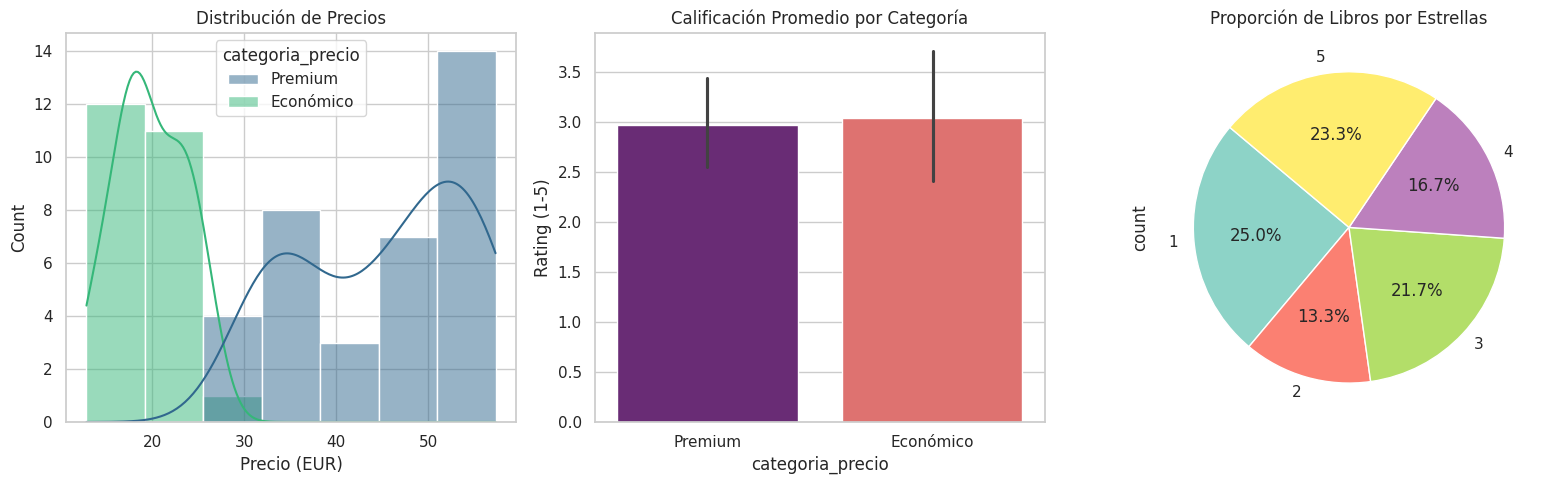

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 5))

# (a) Distribución de precios por categoría
plt.subplot(1, 3, 1)
sns.histplot(data=df_final, x='precio_eur', hue='categoria_precio', kde=True, palette='viridis')
plt.title('Distribución de Precios')
plt.xlabel('Precio (EUR)')

# (b) Calificación promedio por categoría de precio
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='categoria_precio', y='rating_num', estimator='mean', palette='magma')
plt.title('Calificación Promedio por Categoría')
plt.ylabel('Rating (1-5)')

# (c) Gráfico de pastel: Conteo de libros por Rating
plt.subplot(1, 3, 3)
df_final['rating_num'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='Set3')
plt.title('Proporción de Libros por Estrellas')

plt.tight_layout()
plt.show()

In [23]:
df_final.to_excel('Resultado_Final_Libros.xlsx', index=False)


## Conclusiones


Conclusión:
Al realizar esta practica debemos poner atención especial en los símbolos raros que al copiar proovcan un fallo en el  código (símbolo de libra) y estructuras que cambian al copiar y pegar, lo cual llega hacer tedioso y sigue siendo repetitivo en el proceso si no sabemos pulir ese tipo de acciones .

El manejo de las heramientas nos amplia la manera en la que resolvermos los porblemas.

Nos enriquece realizar un proceso mas completo para comprender las activiades a realizar y tener varias opciones para lograr las metas por medios diferentes